# Kerchunk vs netCDF Read Performance for Amon CMIP Datasets

For Amon datasets, netCDF read performance degrades rapidly as file count increases, while kerchunk read time remains largely insensitive to dataset fragmentation.

**Overview**

- Benchmarks read performance for kerchunk references and native netCDF files.
- Uses Amon (monthly mean) CMIP-style datasets.
- Focuses on a single frequency to isolate the effect of dataset fragmentation.

**Key findings**

- NetCDF read time increases strongly with the number of netCDF files.
- Read times span more than an order of magnitude for highly fragmented datasets.
- Kerchunk read time remains relatively stable across the same datasets.
- Kerchunk performance shows weak sensitivity to file count.

**Conclusion**

- For Amon datasets, file count is a dominant driver of netCDF read performance.
- Kerchunk effectively decouples read performance from dataset fragmentation, providing more consistent read times for multi-file datasets.


In [9]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd
from IPython.display import HTML

# Prevent truncation of strings
pd.set_option("display.max_colwidth", None)
# Display floats with two decimal places
pd.options.display.float_format = "{:.2f}".format

## View the Raw Metrics


In [10]:
df_raw = pd.read_csv(
    "riotai/results/20260126_130127/kerchunk_vs_netcdf_raw_20260126_130127.csv"
)
# Filter for "Amon" frequency
df_raw = df_raw[df_raw["frequency"] == "Amon"]

# Add a new column for the difference between kerchunk_time and netcdf_time
df_raw["time_difference"] = df_raw["kerchunk_time"] - df_raw["netcdf_time"]


HTML(
    f"""
<div style="height:400px; overflow-y:scroll;">
    {df_raw.to_html(max_rows=None, max_cols=None, notebook=True)}
</div>
"""
)

,frequency,json,num_netcdf_files,timesteps,dims,kerchunk_time,netcdf_time,time_difference
0,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/historical/mon/CMIP6.CMIP.CNRM-CERFACS.CNRM-CM6-1.historical.r14i1p1f2.Amon.tas.gr.v20191004.kerchunk.json,1,1980,"{'time': 1980, 'lat': 128, 'lon': 256, 'axis_nbounds': 2}",0.52,0.17,0.35
1,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp119/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp119.r6i1p1f1.Amon.tas.gr.v20191122.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.70,0.24,0.47
2,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.ECMWF.ECMWF-IFS-HR.highresSST-present.r5i1p1f1.Amon.pr.gr.v20181119.kerchunk.json,50,618,"{'lat': 361, 'bnds': 2, 'lon': 720, 'time': 618}",0.67,4.43,-3.76
3,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp126/mon/CMIP6.ScenarioMIP.EC-Earth-Consortium.EC-Earth3.ssp126.r139i1p1f1.Amon.tas.gr.v20210615.kerchunk.json,86,1032,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 1032}",0.67,7.60,-6.93
4,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp119/mon/CMIP6.ScenarioMIP.EC-Earth-Consortium.EC-Earth3.ssp119.r114i1p1f1.Amon.tas.gr.v20200412.kerchunk.json,86,1032,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 1032}",0.29,7.76,-7.47
5,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/ta/piControl/mon/CMIP6.CMIP.E3SM-Project.E3SM-1-0.piControl.r1i1p1f1.Amon.ta.gr.v20220109.kerchunk.json,20,6000,"{'lat': 180, 'bnds': 2, 'lon': 360, 'time': 6000, 'plev': 19}",0.32,4.85,-4.53
6,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/tas/ssp370/mon/CMIP6.ScenarioMIP.IPSL.IPSL-CM6A-LR.ssp370.r1i1p1f1.Amon.tas.gr.v20190119.kerchunk.json,1,1032,"{'time': 1032, 'lat': 143, 'lon': 144, 'axis_nbounds': 2}",0.29,0.23,0.06
7,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.MIROC.NICAM16-9S.highresSST-present.r1i1p1f1.Amon.pr.gr.v20190830.kerchunk.json,11,132,"{'lat': 1280, 'bnds': 2, 'lon': 2560, 'time': 132}",0.20,1.32,-1.11
8,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/pr/highresSST-present/mon/CMIP6.HighResMIP.IPSL.IPSL-CM6A-ATM-HR.highresSST-present.r1i1p1f1.Amon.pr.gr.v20190122.kerchunk.json,1,780,"{'time': 780, 'lat': 361, 'lon': 512, 'axis_nbounds': 2}",0.24,0.56,-0.32
9,Amon,/global/cfs/projectdirs/m4931/sasha-tmp/kerchunk/ta/historical/mon/CMIP6.CMIP.EC-Earth-Consortium.EC-Earth3.historical.r143i1p1f1.Amon.ta.gr.v20200412.kerchunk.json,45,540,"{'lat': 256, 'bnds': 2, 'lon': 512, 'time': 540, 'plev': 19}",0.32,6.08,-5.76


### **Plot 1: Kerchunk vs netCDF Read Time**

_(point size = number of netCDF files)_


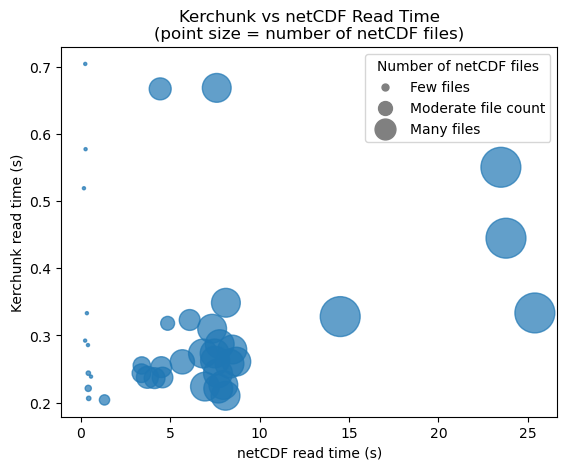

In [12]:
fig, ax = plt.subplots()

sizes = df_raw["num_netcdf_files"] * 5  # scale for visibility

ax.scatter(
    df_raw["netcdf_time"],
    df_raw["kerchunk_time"],
    s=sizes,
    alpha=0.7,
)

ax.set_xlabel("netCDF read time (s)")
ax.set_ylabel("Kerchunk read time (s)")
ax.set_title("Kerchunk vs netCDF Read Time\n(point size = number of netCDF files)")

# Create proxy markers for legend
small = mlines.Line2D(
    [], [], color="gray", marker="o", linestyle="None", markersize=5, label="Few files"
)
medium = mlines.Line2D(
    [],
    [],
    color="gray",
    marker="o",
    linestyle="None",
    markersize=10,
    label="Moderate file count",
)
large = mlines.Line2D(
    [],
    [],
    color="gray",
    marker="o",
    linestyle="None",
    markersize=15,
    label="Many files",
)

ax.legend(handles=[small, medium, large], title="Number of netCDF files")

plt.show()

**Key observations:**

- Kerchunk read times remain clustered (~0.2–0.7 s) across all datasets.
- NetCDF read times vary widely, up to ~25 s.
- Large file counts correspond to long netCDF read times but similar kerchunk times.

**Takeaway:** Kerchunk read performance is largely insensitive to file count, unlike netCDF.


### **Plot 2: netCDF Read Time vs Number of netCDF Files (linear scale)**


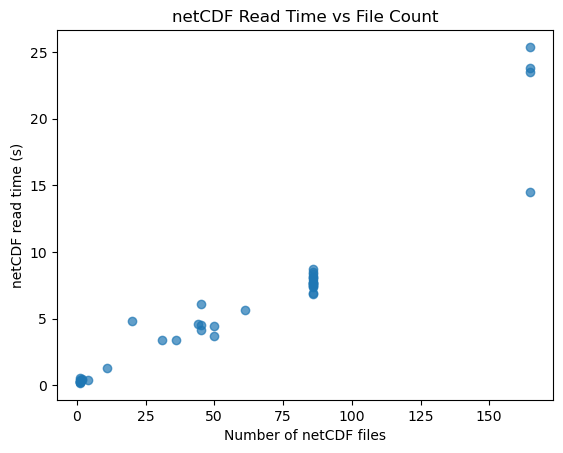

In [13]:
fig, ax = plt.subplots()

ax.scatter(
    df_raw["num_netcdf_files"],
    df_raw["netcdf_time"],
    alpha=0.7,
)

ax.set_xlabel("Number of netCDF files")
ax.set_ylabel("netCDF read time (s)")
ax.set_title("netCDF Read Time vs File Count")

plt.show()

**Key observations:**

- NetCDF read time increases monotonically with file count.
- Single-file datasets are sub-second; O(100+) files reach tens of seconds.

**Takeaway:** File count is the primary driver of netCDF read time for Amon datasets.


### **Plot 3: netCDF Read Time vs Number of netCDF Files (log scale)**


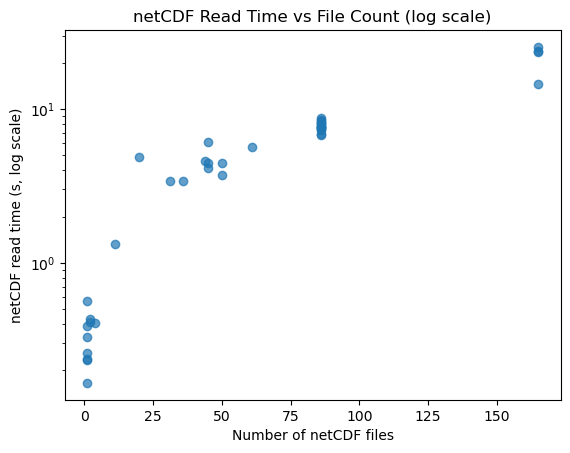

In [14]:
fig, ax = plt.subplots()

ax.scatter(
    df_raw["num_netcdf_files"],
    df_raw["netcdf_time"],
    alpha=0.7,
)

ax.set_yscale("log")

ax.set_xlabel("Number of netCDF files")
ax.set_ylabel("netCDF read time (s, log scale)")
ax.set_title("netCDF Read Time vs File Count (log scale)")

plt.show()

**Key observations:**

- NetCDF read time spans over an order of magnitude.
- Clear clustering occurs at common file counts.

**Takeaway:** NetCDF read time scales systematically with dataset fragmentation.


### Overall takeaway

- NetCDF read time grows rapidly with file count.
- Kerchunk read time remains relatively stable.
- Kerchunk decouples read performance from dataset fragmentation for Amon datasets
